# Distributary Analysis — Total Inundation (Figure 3, Table 1)

Distributary shares of total inundation: monthly areas, seasonal z-scores, the NE-SW
divergence index, and trend/change-point tests (Mann-Kendall, sequential MK, Pettitt,
ANCOVA). Builds **Figure 3** and the total-inundation rows of **Table 1**.

- **Produces:** `Distributary_InundationMonthly_TotalInundation.csv`,
  `Distributary_ZScores{Monthly,Annual}_TotalInundation.csv`,
  `Dryness_Divergence_Annual_TotalInundation.csv`, Figure 3, Table 1.
- **Inputs:** AdDSWE monthly products (EE assets) + `study_areas/Okavango_Distributaries`
  (Dryad `study_areas/`); or the derived distributary CSVs (Dryad `inundation/analysis/distributaries/`).

> Input/output paths are set within the notebook (to be pointed at a local Dryad copy).


# Distributary Inundation Analysis Pipeline

End-to-end pipeline for the AdDSWE distributary-scale flood-pulse analysis. Produces:

1. **Monthly wetted area** per distributary, pulled from GEE AdDSWE assets.
2. **Monthly z-scores** of each distributary's share of delta-wide inundation, computed
   within calendar month against the historical climatology.
3. **Annual mean z-scores** with a >=8-month-per-year inclusion threshold.
4. **Trend and change-point tests** per distributary:
   *conditional* trend-free pre-whitening (Yue et al. 2002; applied only where
   lag-1 autocorrelation is significant, estimated from consecutive-year pairs),
   tie-corrected Mann-Kendall with Benjamini-Hochberg FDR control across the
   seven regions, sequential Mann-Kendall with the classical Sneyers reporting
   criteria, and Pettitt with Monte-Carlo AR(1) significance. Sen's slope is
   used **internally for detrending only** and is not reported as a result.
5. **Annual divergence index** D = NE_mean_z - SW_mean_z (same >=8-month threshold).
6. **Figure 3** -- annual time-series panels, post-2015 mean choropleth, and the
   full-record divergence bar chart.

Run cells in order. The GEE pull (§2) is the only slow step; once the
monthly CSV is written, you can re-run everything downstream without touching
GEE again.

## §0 · Configuration

Set **`DATASET`** to either `'TotalInundation'` (DSWE ≥ 1) or `'OpenWater'` (DSWE ≥ 3).
All downstream filenames pick up this label automatically, **including the figure
output routing**:

| `DATASET` | Composite time-series/map/divergence figure | SMK u(t)/u'(t) diagnostic |
|---|---|---|
| `TotalInundation` | `Figures\Figure3\Figure3_TotalInundation_*` | `Figures\FigureS2\FigureS2_TotalInundation` |
| `OpenWater` | `Figures\FigureS1\FigureS1_OpenWater_*` | `Figures\FigureS3\FigureS3_OpenWater` |

(The composite figure is saved as four assembly pieces sharing the stem:
`_panels_a-g`, `_legend`, `_map_h`, `_panel_i`.)

The other paths point to your local data directories; update them as needed.

In [1]:
# ── User configuration ─────────────────────────────────────────────────────
DATASET = 'TotalInundation'   # 'TotalInundation' (DSWE ≥1) or 'OpenWater' (DSWE ≥3)

# Paths (use raw strings on Windows)
SHAPEFILE_PATH = r"E:\Okavango\Data\Study_Areas\Okavango_Distributaries.shp"
CSV_DIR        = r"E:\Okavango\Data\Inundation\Distributaries"
FIGURE_ROOT    = r"E:\Okavango\Manuscript\Figures"

# ── Derived constants ──────────────────────────────────────────────────────
import os
os.makedirs(CSV_DIR, exist_ok=True)

assert DATASET in ('TotalInundation', 'OpenWater'), \
    f"DATASET must be 'TotalInundation' or 'OpenWater', got {DATASET!r}"

DSWE_THRESHOLD = 1 if DATASET == 'TotalInundation' else 3

# CSV output paths
CSV_MONTHLY  = os.path.join(CSV_DIR, f'Distributary_InundationMonthly_{DATASET}.csv')
CSV_ZMONTHLY = os.path.join(CSV_DIR, f'Distributary_ZScoresMonthly_{DATASET}.csv')
CSV_ZANNUAL  = os.path.join(CSV_DIR, f'Distributary_ZScoresAnnual_{DATASET}.csv')
CSV_TESTS    = os.path.join(CSV_DIR, f'Distributary_TrendTests_{DATASET}.csv')
CSV_DIV      = os.path.join(CSV_DIR, f'Dryness_Divergence_Annual_{DATASET}.csv')

# Figure output routing — depends on which dataset is being analyzed.
#   TotalInundation -> main-text Figure 3 + supplementary Figure S2 (SMK diagnostic)
#   OpenWater       -> supplementary Figures S1 (composite) + S3 (SMK diagnostic)
if DATASET == 'TotalInundation':
    MAIN_FIG_DIR = os.path.join(FIGURE_ROOT, 'Figure3')
    SMK_FIG_DIR  = os.path.join(FIGURE_ROOT, 'FigureS2')
    FIG_OUT_STEM = os.path.join(MAIN_FIG_DIR, f'Figure3_{DATASET}')
    SMK_FIG_STEM = os.path.join(SMK_FIG_DIR,  f'FigureS2_{DATASET}')
else:  # OpenWater
    MAIN_FIG_DIR = os.path.join(FIGURE_ROOT, 'FigureS1')
    SMK_FIG_DIR  = os.path.join(FIGURE_ROOT, 'FigureS3')
    FIG_OUT_STEM = os.path.join(MAIN_FIG_DIR, f'FigureS1_{DATASET}')
    SMK_FIG_STEM = os.path.join(SMK_FIG_DIR,  f'FigureS3_{DATASET}')

os.makedirs(MAIN_FIG_DIR, exist_ok=True)
os.makedirs(SMK_FIG_DIR,  exist_ok=True)

# Distributary names and groups (NEW NAMES — must match shapefile dist_name)
EXPECTED_NAMES = ['Boro', 'Thaoge', 'Xudum', 'Panhandle',
                  'Khwai', 'Magweggana', 'Mboroga']
SW_GROUP = ['Boro', 'Thaoge', 'Xudum']
NE_GROUP = ['Khwai', 'Magweggana', 'Mboroga']
PH_GROUP = ['Panhandle']

# Panel order (top → bottom) for time-series figure
PANEL_ORDER = ['Panhandle', 'Magweggana', 'Khwai', 'Mboroga',
               'Boro', 'Thaoge', 'Xudum']

# Analysis parameters
MIN_MONTHS_PER_YEAR = 8
POST_PERIOD_START   = 2015   # for choropleth post-period mean

# Pettitt break-point window for "significant within window" flagging
BREAK_WINDOW = (2012, 2019)

print(f"Configuration: DATASET={DATASET}, DSWE threshold ≥{DSWE_THRESHOLD}")
print(f"Monthly CSV:    {CSV_MONTHLY}")
print(f"Z-monthly CSV:  {CSV_ZMONTHLY}")
print(f"Z-annual CSV:   {CSV_ZANNUAL}")
print(f"Test stats CSV: {CSV_TESTS}")
print(f"Divergence CSV: {CSV_DIV}")
print(f"Composite figure stem:      {FIG_OUT_STEM}")
print(f"SMK diagnostic figure stem: {SMK_FIG_STEM}")


Configuration: DATASET=TotalInundation, DSWE threshold ≥1
Monthly CSV:    E:\Okavango\Data\Inundation\Distributaries\Distributary_InundationMonthly_TotalInundation.csv
Z-monthly CSV:  E:\Okavango\Data\Inundation\Distributaries\Distributary_ZScoresMonthly_TotalInundation.csv
Z-annual CSV:   E:\Okavango\Data\Inundation\Distributaries\Distributary_ZScoresAnnual_TotalInundation.csv
Test stats CSV: E:\Okavango\Data\Inundation\Distributaries\Distributary_TrendTests_TotalInundation.csv
Divergence CSV: E:\Okavango\Data\Inundation\Distributaries\Dryness_Divergence_Annual_TotalInundation.csv
Composite figure stem:      E:\Okavango\Manuscript\Figures\Figure3\Figure3_TotalInundation
SMK diagnostic figure stem: E:\Okavango\Manuscript\Figures\FigureS2\FigureS2_TotalInundation


## §1 · Load distributary shapefile and verify names

Loads the distributary polygons and **fails loudly** if any of the expected
`dist_name` values are missing. The expected set reflects the renamed
distributaries: `Xhamu → Panhandle`, `TKX → Thaoge`, `Magwegwe → Magweggana`.

In [2]:
import geopandas as gpd

distributaries_gdf = gpd.read_file(SHAPEFILE_PATH)
print(f"Loaded shapefile with {len(distributaries_gdf)} features")
print(f"dist_name values found: {sorted(distributaries_gdf['dist_name'].unique())}")

missing = set(EXPECTED_NAMES) - set(distributaries_gdf['dist_name'].unique())
extra   = set(distributaries_gdf['dist_name'].unique()) - set(EXPECTED_NAMES)

if missing:
    raise ValueError(
        f"Shapefile is missing expected dist_name values: {sorted(missing)}.\n"
        f"Update the shapefile's dist_name field to include all of: {EXPECTED_NAMES}"
    )
if extra:
    print(f"⚠ Note: shapefile has extra dist_name values not in EXPECTED_NAMES: {sorted(extra)}")
    print("  These will be ignored downstream.")

print("\n✓ All expected distributary names present in shapefile.")


Loaded shapefile with 7 features
dist_name values found: ['Boro', 'Khwai', 'Magweggana', 'Mboroga', 'Panhandle', 'Thaoge', 'Xudum']

✓ All expected distributary names present in shapefile.


## §2 · Pull monthly wetted area from GEE

For each distributary and each monthly AdDSWE asset, sums wetted-pixel area
above the DSWE threshold and writes `Distributary_InundationMonthly_<DATASET>.csv`.

This is the slow step (~30+ min depending on GEE load and number of months).
**Skip this cell if the monthly CSV already exists** — the next cell will
load it directly. Re-run only if the underlying AdDSWE assets have changed.

In [3]:
import ee
import pandas as pd

# Authenticate / initialise once per session
try:
    ee.Initialize()
except Exception:
    ee.Authenticate()
    ee.Initialize()

def gdf_to_ee_fc(gdf):
    features = []
    for _, row in gdf.iterrows():
        geom = ee.Geometry(row.geometry.__geo_interface__)
        props = {k: v for k, v in row.items() if k != 'geometry'}
        features.append(ee.Feature(geom, props))
    return ee.FeatureCollection(features)

distributaries_ee = gdf_to_ee_fc(distributaries_gdf)

ASSET_FOLDER = "projects/ee-okavango/assets/water_masks/monthly_DSWE_Landsat_30m_v4/DSWE_Products"

def get_wetted_area(dist_name, year, month, threshold):
    """Return wetted area (km²) for one distributary-month."""
    dist = distributaries_ee.filter(ee.Filter.eq('dist_name', dist_name))
    asset_path = f"{ASSET_FOLDER}/DSWE_{year}_{month:02d}"
    water = ee.Image(asset_path).select(0).rename('water')
    water_mask = water.gte(threshold)
    pixel_area = ee.Image.pixelArea().updateMask(water_mask)
    stats = pixel_area.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=dist.geometry(),
        scale=30,
        maxPixels=1e10,
        bestEffort=True,
    ).getInfo()
    area_m2 = stats.get('area', 0) or 0
    return area_m2 / 1e6

print(f"Listing assets in {ASSET_FOLDER} ...")
asset_list = ee.data.listAssets({'parent': ASSET_FOLDER})['assets']
print(f"Found {len(asset_list)} monthly assets")

records = []
for asset in asset_list:
    name = asset['name'].split('/')[-1]
    try:
        _, yr, mo = name.split('_')
        records.append({'year': int(yr), 'month': int(mo)})
    except ValueError:
        print(f"⚠ Skipping unparseable asset name: {name}")
records = sorted(records, key=lambda r: (r['year'], r['month']))
print(f"Parsed {len(records)} valid year-month combinations")

print(f"\nPulling wetted area for {len(EXPECTED_NAMES)} distributaries × {len(records)} months")
print(f"DSWE threshold: ≥{DSWE_THRESHOLD}  ({DATASET})")

rows = []
for r in records:
    yr, mo = r['year'], r['month']
    row = {'Year': yr, 'Month': mo}
    for d in EXPECTED_NAMES:
        try:
            row[d] = get_wetted_area(d, yr, mo, DSWE_THRESHOLD)
        except Exception as e:
            print(f"  ⚠ {yr}-{mo:02d} {d}: {e}")
            row[d] = float('nan')
    rows.append(row)
    if len(rows) % 20 == 0:
        print(f"  ... {len(rows)} / {len(records)} months done")

df_monthly = pd.DataFrame(rows)
df_monthly.to_csv(CSV_MONTHLY, index=False)
print(f"\n✓ Saved {len(df_monthly)} monthly records to {CSV_MONTHLY}")
df_monthly.head()


Listing assets in projects/ee-okavango/assets/water_masks/monthly_DSWE_Landsat_30m_v4/DSWE_Products ...
Found 368 monthly assets
Parsed 368 valid year-month combinations

Pulling wetted area for 7 distributaries × 368 months
DSWE threshold: ≥1  (TotalInundation)


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x000001B170BBCC10>>
Traceback (most recent call last):
  File "C:\Users\huckr\miniconda3\Lib\site-packages\ipykernel\ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


KeyboardInterrupt: 

## §3 · Compute monthly z-scores

For each distributary, compute the **share of delta-wide inundation** in each
month, then z-score that share against the calendar-month historical distribution
(e.g. all Januaries are pooled to form the January reference distribution).

Output: `Distributary_ZScoresMonthly_<DATASET>.csv` with `Year`, `Month`, one
column per distributary.

In [5]:
import numpy as np
import pandas as pd

df_monthly = pd.read_csv(CSV_MONTHLY)
print(f"Loaded {len(df_monthly)} monthly inundation records from {CSV_MONTHLY}")

total = df_monthly[EXPECTED_NAMES].sum(axis=1)
share = df_monthly[EXPECTED_NAMES].div(total, axis=0)

df_z = df_monthly[['Year', 'Month']].copy()
for d in EXPECTED_NAMES:
    grp = share[d].groupby(df_monthly['Month'])
    mu  = grp.transform('mean')
    sd  = grp.transform('std')
    df_z[d] = (share[d] - mu) / sd

df_z.to_csv(CSV_ZMONTHLY, index=False)
print(f"✓ Saved monthly z-scores to {CSV_ZMONTHLY}")
print(f"\nQuick sanity check (mean ≈ 0, sd ≈ 1):")
print(df_z[EXPECTED_NAMES].agg(['mean', 'std']).round(3).T)


Loaded 368 monthly inundation records from E:\Okavango\Data\Inundation\Distributaries\Distributary_InundationMonthly_TotalInundation.csv
✓ Saved monthly z-scores to E:\Okavango\Data\Inundation\Distributaries\Distributary_ZScoresMonthly_TotalInundation.csv

Quick sanity check (mean ≈ 0, sd ≈ 1):
            mean    std
Boro        -0.0  0.985
Thaoge      -0.0  0.985
Xudum       -0.0  0.985
Panhandle    0.0  0.985
Khwai       -0.0  0.985
Magweggana   0.0  0.985
Mboroga      0.0  0.985


## §4 · Aggregate to annual mean z-scores

Average each distributary's monthly z-scores within each calendar year. **Years
with fewer than 8 valid months are excluded** to avoid biased annual means
during the 2010–2012 data gap and other sparse years.

Output: `Distributary_ZScoresAnnual_<DATASET>.csv` with `Year`, `n_months`, and
one column per distributary.

In [6]:
df_z = pd.read_csv(CSV_ZMONTHLY)
print(f"Loaded monthly z-scores: {len(df_z)} rows")

n_months = df_z.groupby('Year').size().rename('n_months')
annual_means = df_z.groupby('Year')[EXPECTED_NAMES].mean()
annual_means = annual_means.join(n_months)

keep_mask = annual_means['n_months'] >= MIN_MONTHS_PER_YEAR
df_annual = annual_means[keep_mask].copy().reset_index()
df_annual = df_annual[['Year', 'n_months'] + EXPECTED_NAMES]

dropped = sorted(annual_means.index[~keep_mask].tolist())
print(f"Years retained: {len(df_annual)} (range {int(df_annual.Year.min())}"
      f"–{int(df_annual.Year.max())})")
print(f"Years dropped (< {MIN_MONTHS_PER_YEAR} months): {dropped}")

df_annual.to_csv(CSV_ZANNUAL, index=False)
print(f"\n✓ Saved annual z-scores to {CSV_ZANNUAL}")
df_annual.head()


Loaded monthly z-scores: 368 rows
Years retained: 31 (range 1989–2025)
Years dropped (< 8 months): [1984, 1986, 1987, 2003, 2008, 2009, 2010]

✓ Saved annual z-scores to E:\Okavango\Data\Inundation\Distributaries\Distributary_ZScoresAnnual_TotalInundation.csv


,Year,n_months,Boro,Thaoge,Xudum,Panhandle,Khwai,Magweggana,Mboroga
0,1989,10,1.224631,1.519726,0.753825,-1.281337,-0.327753,0.683939,-1.243637
1,1990,10,0.590867,0.554366,-0.116232,0.065083,-0.187779,-0.172663,-0.588993
2,1991,10,1.085672,0.684770,0.006324,-0.533196,-0.254598,-0.735426,-0.480841
3,1992,12,0.879987,0.347075,0.155111,0.107569,-0.649893,-0.382260,-0.769287
4,1993,10,-0.153863,0.791136,-0.873970,0.208781,-0.158222,0.938629,0.080975


## §5 · Trend and change-point tests

For each distributary's annual z-score series, the following procedures are applied.
Design choices follow the most common conventions in the hydrologic trend-detection
literature; each is annotated with its rationale.

**1. Conditional Trend-Free Pre-Whitening (TFPW)** — Yue, Pilon, Phinney & Cavadias (2002).
The series is detrended with Sen's slope, lag-1 autocorrelation (r₁) is estimated from
the residuals, the residuals are pre-whitened, and the trend is added back. Three
implementation details matter for this dataset:

- **r₁ is estimated from consecutive-year pairs only.** Pairs spanning the data gaps
  (2002→2004, 2007→2013) are *not* lag-1 pairs and are excluded from the estimate.
- **Pre-whitening is applied conditionally** — only where |r₁| exceeds its two-sided
  95% significance threshold (1.96/√n_pairs). Whitening with a noise-level r₁ estimate
  on a ~31-point record distorts more than it corrects (Douglas et al. 2000).
- **The whitening weight decays as r₁^Δ across gap years**, since an AR(1) process has
  lag-k correlation r₁ᵏ; treating a 6-year gap as a lag-1 step would over-whiten.

Sen's slope is computed as machinery for the detrending step. Because the analyzed
variable is a standardized share anomaly, trend magnitudes in slope units are not
interpretable and are **not reported in Results**; the magnitude of inundation
redistribution is quantified elsewhere in the manuscript.

**2. Mann-Kendall trend test** (Mann 1945; Kendall 1975) with tie-corrected variance,
run on the conditionally-TFPW'd series. Effect size is reported as Kendall's τ
(unitless, rank-based). Because seven regions are tested simultaneously,
**Benjamini-Hochberg FDR control** (Benjamini & Hochberg 1995)
is applied across the family of seven p-values at α = 0.05.

**3. Sequential Mann-Kendall (SMK)** — Sneyers (1990) — on the same series used for MK.
A u/u' crossing is reported as a **trend onset** only when the classical criteria hold:

- (a) the crossing lies within ±1.96;
- (b) u(t) subsequently exceeds ±1.96 *and* remains outside the band through the series end;
- (c) the global (FDR-corrected) MK test is significant;
- (d) the crossing is outside the unstable early window (first 8 points) and not
  adjacent to a data-gap edge.

A crossing failing **only (a)** — the curves intersect already outside the band while
(b)–(d) hold — indicates the trend was established *before* the crossing; it is
reported as "**established by [year]**, onset unresolvable" (typically the onset falls
inside the 2008–2012 gap) rather than discarded. All other crossings are
non-significant fluctuations and are logged but not interpreted.

**4. Pettitt change-point test** (Pettitt 1979) on the **raw (un-whitened)** annual
series — TFPW's detrending step partially absorbs genuine steps into a fitted slope,
so the raw series is the correct input. However, the closed-form Pettitt p-value
assumes independent observations and its false-positive rate inflates badly under the
positive serial correlation present here (Serinaldi & Kilsby 2016). Significance is
therefore assessed with a **Monte-Carlo AR(1) null**: the empirical distribution of
Pettitt's K is built from 100,000 stationary AR(1) surrogate series with each
distributary's observed r₁ and record length. The nominal p-value is retained in the
output table for reference only; inference uses the Monte-Carlo p-value.

Output: `Distributary_TrendTests_<DATASET>.csv` with one row per distributary.

### §5.1 · Statistical primitives

Sen's slope (detrending only), consecutive-pair lag-1 autocorrelation, conditional
TFPW, tie-corrected Mann-Kendall, and Benjamini-Hochberg FDR.

In [7]:
from itertools import combinations

import numpy as np
import pandas as pd
from scipy.stats import rankdata, norm

df_annual = pd.read_csv(CSV_ZANNUAL)
years_arr = df_annual['Year'].values.astype(float)
print(f"Loaded {len(df_annual)} annual records ({int(years_arr.min())}-{int(years_arr.max())})")


def sens_slope(y, t):
    """Theil-Sen slope (median of pairwise slopes).
    Used ONLY for detrending inside TFPW; not reported as a result."""
    return np.median([(y[j] - y[i]) / (t[j] - t[i])
                      for i, j in combinations(range(len(y)), 2)
                      if t[j] != t[i]])


def lag1_consecutive(values, years):
    """Lag-1 autocorrelation estimated from CONSECUTIVE-YEAR pairs only.
    Pairs spanning data gaps (e.g. 2007->2013) are not lag-1 pairs and
    would contaminate the estimate, so they are excluded."""
    values = np.asarray(values, float)
    years = np.asarray(years, float)
    keep = np.where(np.diff(years) == 1)[0]
    if len(keep) < 3:
        return np.nan, len(keep)
    r1 = np.corrcoef(values[keep], values[keep + 1])[0, 1]
    return r1, len(keep)


def tfpw_conditional(y, years, alpha_z=1.96):
    """Conditional Trend-Free Pre-Whitening (Yue et al. 2002).

    1. Detrend with Sen's slope.
    2. Estimate lag-1 AC from consecutive-year pairs of the residuals.
    3. Pre-whiten ONLY if |r1| exceeds its two-sided 95% significance
       threshold (1.96/sqrt(n_pairs)); otherwise return the original
       series untouched (conditional application per Douglas et al. 2000).
    4. Whitening weight decays as r1**gap across missing years, since an
       AR(1) process has lag-k correlation r1**k.
    5. The first observation is retained (unwhitened) so the blended
       series stays aligned with `years` for SMK year mapping.
    """
    y = np.asarray(y, float)
    t = np.asarray(years, float)
    b = sens_slope(y, t)
    trend = b * (t - t[0])
    detr = y - trend
    r1, n_pairs = lag1_consecutive(detr, t)
    thresh = alpha_z / np.sqrt(n_pairs) if n_pairs > 0 else np.inf
    applied = bool(np.isfinite(r1) and abs(r1) > thresh)
    if not applied:
        return {'blended': y.copy(), 'years': t.copy(), 'slope': b, 'r1': r1,
                'r1_npairs': n_pairs, 'r1_thresh': thresh, 'whitened': False}
    w = np.empty_like(detr)
    w[0] = detr[0]
    for i in range(1, len(detr)):
        gap = t[i] - t[i - 1]
        w[i] = detr[i] - (r1 ** gap) * detr[i - 1]
    return {'blended': w + trend, 'years': t.copy(), 'slope': b, 'r1': r1,
            'r1_npairs': n_pairs, 'r1_thresh': thresh, 'whitened': True}


def mk_test(y):
    """Mann-Kendall trend test with tie-corrected variance.
    Returns (S, Z, p, tau). Tau is tau-a = S / (n(n-1)/2), derived from
    the same S used for Z and p so effect size and significance stay
    internally consistent (the z-score series is continuous, so the tie
    correction is immaterial but included for completeness)."""
    y = np.asarray(y, float)
    n = len(y)
    s = sum(np.sign(y[i + 1:] - y[i]).sum() for i in range(n - 1))
    _, counts = np.unique(y, return_counts=True)
    tie_term = np.sum(counts * (counts - 1) * (2 * counts + 5))
    var_s = (n * (n - 1) * (2 * n + 5) - tie_term) / 18.0
    if s > 0:
        z = (s - 1) / np.sqrt(var_s)
    elif s < 0:
        z = (s + 1) / np.sqrt(var_s)
    else:
        z = 0.0
    p = 2 * (1 - norm.cdf(abs(z)))
    tau = s / (0.5 * n * (n - 1))
    return s, z, p, tau


def bh_fdr(pvals, alpha=0.05):
    """Benjamini-Hochberg FDR control across the family of tests.
    Returns (reject boolean array, BH-adjusted p-values)."""
    p = np.asarray(pvals, float)
    m = len(p)
    order = np.argsort(p)
    adj = p[order] * m / np.arange(1, m + 1)
    adj = np.minimum.accumulate(adj[::-1])[::-1]   # enforce monotonicity
    adj = np.minimum(adj, 1.0)
    p_adj = np.empty(m)
    p_adj[order] = adj
    return p_adj <= alpha, p_adj


print("Statistical primitives defined.")

Loaded 31 annual records (1989-2025)
Statistical primitives defined.


### §5.2 · Sequential Mann-Kendall machinery

Progressive u(t) / retrograde u'(t) statistics, crossing detection, and the
Sneyers reporting criteria (a)-(d). Crossings are never silently filtered:
every crossing is classified and logged with the criteria it fails.

In [8]:
EARLY_WINDOW_N = 8   # first 8 points: u(t) variance too large to interpret
SMK_SIG = 1.96       # 95% confidence bounds


def smk(y):
    """Sequential Mann-Kendall (Sneyers 1990): progressive u(t) and
    retrograde u'(t)."""
    def one_dir(x):
        m = np.array([np.sum(x[:i] < x[i]) for i in range(len(x))])
        s = np.cumsum(m)
        k = np.arange(1, len(x) + 1)
        E = k * (k - 1) / 4.0
        V = k * (k - 1) * (2 * k + 5) / 72.0
        with np.errstate(invalid='ignore', divide='ignore'):
            return np.where(V > 0, (s - E) / np.sqrt(V), 0.0)
    return one_dir(y), -one_dir(y[::-1])[::-1]


def gap_edge_years(years):
    """Years in the record that sit immediately adjacent to a data gap."""
    yrs = set(int(y) for y in years)
    missing = set(range(min(yrs), max(yrs) + 1)) - yrs
    return {y for y in yrs if (y - 1) in missing or (y + 1) in missing}


def find_smk_crossings(u_fwd, u_bwd, years):
    """All u/u' sign-change intersections, with linearly interpolated year
    and the interpolated u value at the crossing."""
    diff = u_fwd - u_bwd
    out = []
    for i in range(len(years) - 1):
        if np.isnan(diff[i]) or np.isnan(diff[i + 1]):
            continue
        if np.sign(diff[i]) != np.sign(diff[i + 1]) and (diff[i] != 0 or diff[i + 1] != 0):
            frac = abs(diff[i]) / (abs(diff[i]) + abs(diff[i + 1]))
            yr = years[i] + frac * (years[i + 1] - years[i])
            u_at = u_fwd[i] + frac * (u_fwd[i + 1] - u_fwd[i])
            out.append({'year': float(yr), 'idx': i, 'u_at_cross': float(u_at)})
    return out


def classify_crossing(c, u_fwd, mk_sig_fdr, edges,
                      sig=SMK_SIG, early_n=EARLY_WINDOW_N):
    """Sneyers reporting criteria for one crossing:
      (a) the crossing lies within +/-1.96;
      (b) u(t) subsequently exceeds +/-1.96 AND remains outside at series end;
      (c) the global (FDR-corrected) MK test is significant;
      (d) outside the early unstable window and not adjacent to a gap edge.

    Special case: a crossing failing ONLY (a) -- the curves intersect
    already outside the band while (b)-(d) hold -- means the trend was
    established BEFORE the crossing. The onset predates it (often inside
    a data gap) and is reported as 'established_by' rather than discarded.
    """
    idx, u_at, yr = c['idx'], c['u_at_cross'], c['year']
    fails = []
    if abs(u_at) > sig:
        fails.append('a: crossing outside +/-%.2f' % sig)
    post = u_fwd[idx + 1:]
    if not (len(post) and np.any(np.abs(post) > sig)):
        fails.append('b: u(t) never exceeds bounds afterward')
    elif abs(u_fwd[-1]) <= sig:
        fails.append('b: u(t) exceeds but returns inside bounds')
    if not mk_sig_fdr:
        fails.append('c: global MK not significant (FDR)')
    early = idx < early_n
    if early:
        fails.append('d: within early unstable window (first %d points)' % early_n)
    near_gap = int(np.floor(yr)) in edges or int(np.ceil(yr)) in edges
    if near_gap and not early:
        fails.append('d: adjacent to data-gap edge')
    if not fails:
        return 'onset', fails
    if fails == ['a: crossing outside +/-%.2f' % sig]:
        return 'established_by', fails
    return 'fluctuation', fails


GAP_EDGES = gap_edge_years(years_arr)
print(f"Gap-edge years (crossings adjacent to these are flagged): {sorted(GAP_EDGES)}")

Gap-edge years (crossings adjacent to these are flagged): [2002, 2004, 2007, 2013]


### §5.3 · Pettitt test with Monte-Carlo AR(1) significance

The rank-based Pettitt statistic is computed on the **raw** annual series.
The closed-form p-value (independence-assuming) is retained for reference,
but inference uses an empirical null: 100,000 stationary AR(1) surrogates
with the distributary's observed lag-1 autocorrelation. With r1 ~ 0.4-0.7
on a 31-point record, the nominal test's false-positive rate is badly
inflated, and marginal nominal p-values (~0.01-0.03) can lose significance
under the corrected null -- which is the honest result to report.

In [9]:
N_SIM = 100_000
RNG_SEED = 42


def pettitt(x):
    """Pettitt (1979) change-point test (rank formulation).
    Returns change-point index, K statistic, and the NOMINAL p-value
    (kept for reference; inference uses the Monte-Carlo p-value)."""
    x = np.asarray(x, float)
    n = len(x)
    r = rankdata(x)
    t_idx = np.arange(1, n + 1)
    U_t = 2 * np.cumsum(r) - t_idx * (n + 1)
    tau = int(np.argmax(np.abs(U_t)))
    K = float(np.abs(U_t[tau]))
    p = min(2.0 * np.exp(-6.0 * K ** 2 / (n ** 3 + n ** 2)), 1.0)
    return {'tau': tau, 'K': K, 'p_nominal': p}


def pettitt_mc_pvalue(K_obs, n, r1, n_sim=N_SIM, seed=RNG_SEED):
    """Monte-Carlo p-value for Pettitt's K under a stationary AR(1) null.

    Implementation notes (documented for methods):
    - r1 is the lag-1 AC of the Sen-detrended residuals (consecutive-year
      pairs only), i.e. the same estimate used by conditional TFPW.
    - Pettitt's K is rank-based and therefore scale-invariant, so
      unit-variance surrogates suffice.
    - Surrogates are generated as gap-free length-n series; the real
      record's gaps weaken cross-gap correlation, so this choice is
      mildly conservative.
    - The same code path is used for all distributaries: where r1 is
      small, the AR(1) null is effectively white noise and the MC
      p-value converges to the nominal one.
    """
    rng = np.random.default_rng(seed)
    r1_eff = 0.0 if not np.isfinite(r1) else float(r1)
    x = np.empty((n_sim, n))
    x[:, 0] = rng.standard_normal(n_sim)
    innov_sd = np.sqrt(max(1.0 - r1_eff ** 2, 1e-12))
    for t in range(1, n):
        x[:, t] = r1_eff * x[:, t - 1] + innov_sd * rng.standard_normal(n_sim)
    ranks = rankdata(x, axis=1)
    t_idx = np.arange(1, n + 1)
    U = 2 * np.cumsum(ranks, axis=1) - t_idx * (n + 1)
    K_sim = np.max(np.abs(U), axis=1)
    return float((1 + np.sum(K_sim >= K_obs)) / (n_sim + 1))


print(f"Pettitt + Monte-Carlo machinery defined (N_SIM = {N_SIM:,}).")

Pettitt + Monte-Carlo machinery defined (N_SIM = 100,000).


### §5.4 · Run all tests and assemble the results table

Two passes: (1) conditional TFPW + Mann-Kendall for all seven distributaries,
so that BH-FDR can be applied across the full family of p-values; (2) SMK
classification and Pettitt with Monte-Carlo significance.

`results_by_dist` keeps the Figure 3 contract: `mk_sig` is **FDR-based**,
`pet_sig` is **Monte-Carlo-based**, and `smk_onset_year` holds only onsets
that pass all four Sneyers criteria ('established_by' cases are carried
separately and drawn distinctly in Figure S2).

In [10]:
# ── Pass 1: conditional TFPW + MK for every distributary ──────────────────
interim = {}
for d in EXPECTED_NAMES:
    y_raw = df_annual[d].values.astype(float)
    tf = tfpw_conditional(y_raw, years_arr)
    s_mk, z_mk, p_mk, tau_mk = mk_test(tf['blended'])
    interim[d] = dict(y_raw=y_raw, tfpw=tf, mk=(s_mk, z_mk, p_mk, tau_mk))
    print(f"{d:<11} r1={tf['r1']:+.3f} ({tf['r1_npairs']} consecutive pairs, "
          f"95% thresh +/-{tf['r1_thresh']:.3f}) -> "
          f"{'TFPW applied' if tf['whitened'] else 'original series used'}")

# ── BH-FDR across the seven MK p-values ────────────────────────────────────
p_raw = np.array([interim[d]['mk'][2] for d in EXPECTED_NAMES])
rejected, p_adj = bh_fdr(p_raw, alpha=0.05)
for d, rej, pa in zip(EXPECTED_NAMES, rejected, p_adj):
    interim[d]['mk_sig_fdr'] = bool(rej)
    interim[d]['mk_p_fdr'] = float(pa)

# ── Pass 2: SMK classification + Pettitt with Monte-Carlo significance ────
rows = []
results_by_dist = {}
for d in EXPECTED_NAMES:
    it = interim[d]
    tf = it['tfpw']
    y_blended, yrs_blended = tf['blended'], tf['years']
    s_mk, z_mk, p_mk, tau_mk = it['mk']

    # SMK
    u_fwd, u_bwd = smk(y_blended)
    crossings = find_smk_crossings(u_fwd, u_bwd, yrs_blended)
    onset_year, established_by, cross_log = None, None, []
    for c in crossings:
        status, fails = classify_crossing(c, u_fwd, it['mk_sig_fdr'], GAP_EDGES)
        c['status'], c['fails'] = status, fails
        cross_log.append(f"{c['year']:.1f}:{status}")
        if status == 'onset' and onset_year is None:
            onset_year = int(round(c['year']))
        if status == 'established_by' and established_by is None:
            established_by = int(round(c['year']))
    if onset_year is not None:
        smk_status = f"onset {onset_year}"
    elif established_by is not None:
        smk_status = f"established by {established_by} (onset unresolvable)"
    else:
        smk_status = "none"

    # Pettitt (raw series) + Monte-Carlo p-value
    pet = pettitt(it['y_raw'])
    p_mc = pettitt_mc_pvalue(pet['K'], len(it['y_raw']), tf['r1'])
    cp_year = int(years_arr[pet['tau']])
    pet_sig = p_mc < 0.05
    pre_mean = float(np.mean(it['y_raw'][:pet['tau'] + 1]))
    post_mean = float(np.mean(it['y_raw'][pet['tau'] + 1:]))

    rows.append({
        'Distributary': d,
        'n_years': len(years_arr),
        'lag1_AC': round(tf['r1'], 3),
        'lag1_npairs': tf['r1_npairs'],
        'TFPW_applied': tf['whitened'],
        'MK_tau': round(tau_mk, 3),
        'MK_Z': round(z_mk, 3),
        'MK_p': round(p_mk, 5),
        'MK_p_FDR': round(it['mk_p_fdr'], 5),
        'MK_sig_FDR': it['mk_sig_fdr'],
        'SMK_status': smk_status,
        'SMK_onset_year': onset_year,
        'SMK_all_crossings': '; '.join(cross_log) or 'none',
        'Pettitt_cp_year': cp_year,
        'Pettitt_K': round(pet['K'], 1),
        'Pettitt_p_nominal': round(pet['p_nominal'], 5),
        'Pettitt_p_MC': round(p_mc, 5),
        'Pettitt_significant': pet_sig,                       # Monte-Carlo based
        'Pettitt_sig_within_window':
            pet_sig and BREAK_WINDOW[0] <= cp_year <= BREAK_WINDOW[1],
        'pre_mean_zscore': round(pre_mean, 3),
        'post_mean_zscore': round(post_mean, 3),
        'delta_zscore': round(post_mean - pre_mean, 3),
    })
    results_by_dist[d] = {
        'tfpw': tf, 'u_fwd': u_fwd, 'u_bwd': u_bwd,
        'years_blended': yrs_blended, 'crossings': crossings,
        'pettitt': pet, 'pettitt_p_mc': p_mc, 'cp_year': cp_year,
        'pre_mean': pre_mean, 'post_mean': post_mean,
        'mk_z': z_mk, 'mk_tau': tau_mk, 'mk_p': p_mk,
        'mk_p_fdr': it['mk_p_fdr'],
        'mk_sig': it['mk_sig_fdr'],        # Figure 3 contract: FDR-based
        'pet_sig': pet_sig,                # Figure 3 contract: Monte-Carlo based
        'smk_onset_year': onset_year,      # Figure 3 contract: reportable onsets only
        'smk_established_by': established_by,
        'smk_status': smk_status,
    }

df_tests = pd.DataFrame(rows)
df_tests.to_csv(CSV_TESTS, index=False)
print(f"\n[ok] Saved test results to {CSV_TESTS}\n")

display_cols = ['Distributary', 'lag1_AC', 'TFPW_applied',
                'MK_tau', 'MK_Z', 'MK_p', 'MK_p_FDR', 'MK_sig_FDR',
                'SMK_status',
                'Pettitt_cp_year', 'Pettitt_p_nominal', 'Pettitt_p_MC',
                'Pettitt_significant']
print(df_tests[display_cols].to_string(index=False))

Boro        r1=+0.400 (28 consecutive pairs, 95% thresh +/-0.370) -> TFPW applied
Thaoge      r1=+0.317 (28 consecutive pairs, 95% thresh +/-0.370) -> original series used
Xudum       r1=+0.511 (28 consecutive pairs, 95% thresh +/-0.370) -> TFPW applied
Panhandle   r1=+0.083 (28 consecutive pairs, 95% thresh +/-0.370) -> original series used
Khwai       r1=+0.693 (28 consecutive pairs, 95% thresh +/-0.370) -> TFPW applied
Magweggana  r1=+0.465 (28 consecutive pairs, 95% thresh +/-0.370) -> TFPW applied
Mboroga     r1=+0.507 (28 consecutive pairs, 95% thresh +/-0.370) -> TFPW applied

[ok] Saved test results to E:\Okavango\Data\Inundation\Distributaries\Distributary_TrendTests_TotalInundation.csv

Distributary  lag1_AC  TFPW_applied  MK_tau   MK_Z    MK_p  MK_p_FDR  MK_sig_FDR                               SMK_status  Pettitt_cp_year  Pettitt_p_nominal  Pettitt_p_MC  Pettitt_significant
        Boro    0.400          True  -0.574 -4.521 0.00001   0.00004        True                     

### §5.5 · Mean change-point year among significant-within-window distributaries

The headline number for the figure caption and the regime-shift framing in the
manuscript text. Significance is now **Monte-Carlo based**, so this set may be
smaller than under the nominal Pettitt p-values; the 2012-2019 window is a
reporting device for synthesis, not part of any test.

In [12]:
sig_in_window = df_tests[df_tests['Pettitt_sig_within_window']].copy()
print(f"Distributaries with Monte-Carlo Pettitt p<0.05 AND cp in {BREAK_WINDOW}:")
print(sig_in_window[['Distributary', 'Pettitt_cp_year', 'Pettitt_p_MC']]
      .to_string(index=False))

if len(sig_in_window) > 0:
    mean_cp = sig_in_window['Pettitt_cp_year'].mean()
    print(f"\nMean Pettitt change-point year: {mean_cp:.2f}")
    print(f"Rounded:                        {int(round(mean_cp))}")
else:
    print("\n(no distributaries meet both criteria)")

Distributaries with Monte-Carlo Pettitt p<0.05 AND cp in (2012, 2019):
Distributary  Pettitt_cp_year  Pettitt_p_MC
        Boro             2013       0.00425
      Thaoge             2014       0.04628

Mean Pettitt change-point year: 2013.50
Rounded:                        2014


### §5.6 · Figure S2/S3 — SMK diagnostic panels

u(t) and u'(t) per distributary on the (conditionally TFPW'd) series, with:

- **solid green line** — SMK trend onset passing all four Sneyers criteria;
- **dashed green line** — 'established-by' year (crossing outside the band with
  criteria b-d met; onset unresolvable, labeled with a <= prefix);
- **dotted purple line** — Pettitt change point, drawn only when the
  **Monte-Carlo** p-value < 0.05.

Per-panel stats line shows MK tau with the FDR-adjusted p-value and the Pettitt
change point with its Monte-Carlo p-value.

Output path follows the `DATASET` switch in §0: `FigureS2_TotalInundation` under
`Figures\FigureS2` for the main analysis, `FigureS3_OpenWater` under
`Figures\FigureS3` for the open-water variant.

  [ok] Saved E:\Okavango\Manuscript\Figures\FigureS2\FigureS2_TotalInundation.png
  [ok] Saved E:\Okavango\Manuscript\Figures\FigureS2\FigureS2_TotalInundation.pdf
  [ok] Saved E:\Okavango\Manuscript\Figures\FigureS2\FigureS2_TotalInundation.jpg


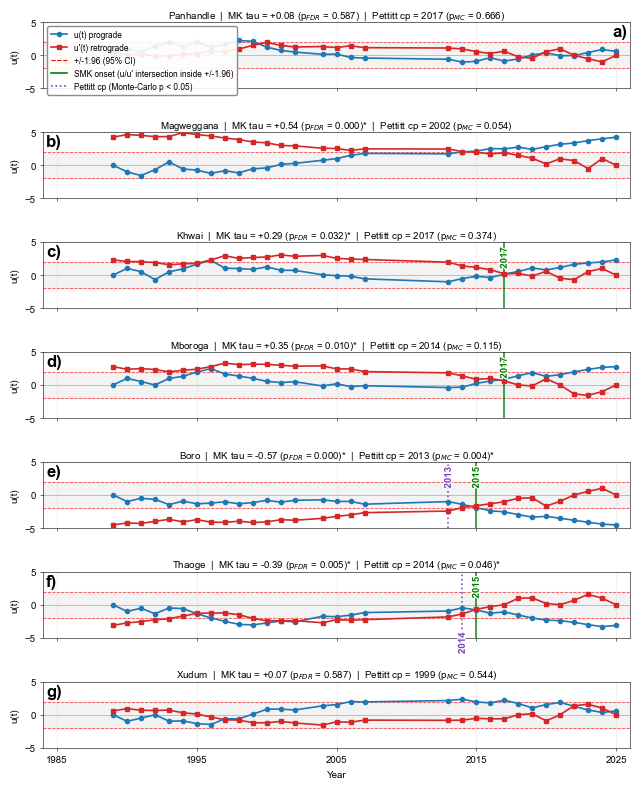

In [13]:
import os

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

PANEL_ORDER_DIAG = ['Panhandle', 'Magweggana', 'Khwai', 'Mboroga',
                    'Boro', 'Thaoge', 'Xudum']
PANEL_LETTERS = list('abcdefg')

LETTER_SIZE = 12
BODY_SIZE = 7
SMK_COLOR = 'green'
PET_COLOR = '#7B3FBF'

plt.rcParams['font.family'] = 'Arial'

fig_smk, axes = plt.subplots(len(PANEL_ORDER_DIAG), 1,
                             figsize=(6.5, 8), sharex=True)

for ax, dist, letter in zip(axes, PANEL_ORDER_DIAG, PANEL_LETTERS):
    r = results_by_dist[dist]
    yrs = r['years_blended']
    u_f, u_b = r['u_fwd'], r['u_bwd']

    ax.axhspan(-1.96, 1.96, color='lightgray', alpha=0.25, zorder=0)
    ax.axhline(1.96, color='red', lw=0.6, ls='--', alpha=0.7, zorder=1)
    ax.axhline(-1.96, color='red', lw=0.6, ls='--', alpha=0.7, zorder=1)
    ax.axhline(0, color='gray', lw=0.5, alpha=0.6, zorder=1)

    ax.plot(yrs, u_f, 'o-', color='C0', lw=1.2, markersize=3,
            label='u(t) prograde', zorder=3)
    ax.plot(yrs, u_b, 's-', color='C3', lw=1.2, markersize=3,
            label="u'(t) retrograde", zorder=3)

    # --- SMK onset (all criteria met): solid green ---
    onset_yr = r['smk_onset_year']
    if onset_yr is not None:
        ax.axvline(onset_yr, color=SMK_COLOR, lw=1.2, ls='-',
                   alpha=0.85, zorder=2)
        ax.text(onset_yr, 4.2, str(onset_yr),
                fontsize=BODY_SIZE, color=SMK_COLOR, fontweight='bold',
                rotation=90, rotation_mode='anchor',
                ha='right', va='center', zorder=4,
                path_effects=[pe.withStroke(linewidth=1.8, foreground='white')])

    # --- Pettitt change point (Monte-Carlo significant): dotted purple ---
    pet_yr = r['cp_year']
    if r['pet_sig']:
        ax.axvline(pet_yr, color=PET_COLOR, lw=1.2, ls=':',
                   alpha=0.9, zorder=2)
        coincident = (onset_yr is not None and abs(onset_yr - pet_yr) <= 1)
        ax.text(pet_yr, -4.2 if coincident else 4.2, str(pet_yr),
                fontsize=BODY_SIZE, color=PET_COLOR, fontweight='bold',
                rotation=90, rotation_mode='anchor',
                ha='right', va='center', zorder=4,
                path_effects=[pe.withStroke(linewidth=1.8, foreground='white')])

    mk_star = '*' if r['mk_sig'] else ''
    pet_star = '*' if r['pet_sig'] else ''
    ax.set_title(
        f"{dist}  |  MK tau = {r['mk_tau']:+.2f} "
        f"(p$_{{FDR}}$ = {r['mk_p_fdr']:.3f}){mk_star}  |  "
        f"Pettitt cp = {pet_yr} (p$_{{MC}}$ = {r['pettitt_p_mc']:.3f}){pet_star}",
        fontsize=BODY_SIZE, pad=3,
    )

    ax.set_ylabel('u(t)', fontsize=BODY_SIZE)
    ax.set_ylim(-5, 5)
    ax.set_xlim(1984, 2026)
    year_ticks = [1985, 1995, 2005, 2015, 2025]
    ax.set_xticks(year_ticks)
    ax.set_xticklabels(year_ticks, fontsize=BODY_SIZE)
    for t in ax.get_yticklabels():
        t.set_fontsize(BODY_SIZE)
    ax.tick_params(axis='both', labelsize=BODY_SIZE, length=2, width=0.4)
    ax.grid(True, alpha=0.3, lw=0.4)
    for s in ax.spines.values():
        s.set_linewidth(0.4)

    if letter == 'a':
        ax.text(0.995, 0.97, f"{letter})", transform=ax.transAxes,
                fontsize=LETTER_SIZE, fontweight='bold',
                va='top', ha='right', zorder=10)
    else:
        ax.text(0.005, 0.97, f"{letter})", transform=ax.transAxes,
                fontsize=LETTER_SIZE, fontweight='bold',
                va='top', ha='left', zorder=10)

handles, labels = axes[0].get_legend_handles_labels()
handles.extend([
    Line2D([0], [0], color='red', lw=0.8, ls='--', label='+/-1.96 (95% CI)'),
    Line2D([0], [0], color=SMK_COLOR, lw=1.2, ls='-',
           label="SMK onset (u/u' intersection inside +/-1.96)"),
    Line2D([0], [0], color=PET_COLOR, lw=1.2, ls=':',
           label='Pettitt cp (Monte-Carlo p < 0.05)'),
])
labels.extend(['+/-1.96 (95% CI)',
               "SMK onset (u/u' intersection inside +/-1.96)",
               'Pettitt cp (Monte-Carlo p < 0.05)'])
axes[0].legend(handles, labels, loc='upper left',
               fontsize=BODY_SIZE - 1, ncol=1, frameon=True,
               edgecolor='gray', framealpha=0.9)

axes[-1].set_xlabel('Year', fontsize=BODY_SIZE)
plt.tight_layout()

smk_diag_stem = SMK_FIG_STEM   # routed by the DATASET switch in §0
for ext in ('png', 'pdf', 'jpg'):
    path = f'{smk_diag_stem}.{ext}'
    if ext == 'jpg':
        fig_smk.savefig(path, dpi=1000, bbox_inches='tight', facecolor='white')
    else:
        fig_smk.savefig(path, dpi=1000, bbox_inches='tight', transparent=True)
    print(f"  [ok] Saved {path}")

plt.show()

## §6 · Compute annual NE − SW divergence index

For each year passing the ≥8-month threshold, compute the within-group mean
z-score for NE and SW distributaries, then:

$$D_t = \overline{z}_{NE,t} - \overline{z}_{SW,t}$$

Panhandle is excluded from both groups. A positive D means the NE distributaries
are capturing a larger-than-typical share relative to the SW distributaries
that year.

Note on the pre/post comparison below: the 2011–2012 years are absent from both
groups **automatically** — they fail the ≥8-month inclusion filter — so their
exclusion is a property of the data coverage, not a discretionary analytical
choice. State this explicitly in methods.

In [14]:
from scipy.stats import mannwhitneyu

ne_mean = df_annual[NE_GROUP].mean(axis=1)
sw_mean = df_annual[SW_GROUP].mean(axis=1)

df_div = pd.DataFrame({
    'Year':    df_annual['Year'].astype(int),
    'NE_mean': ne_mean.round(4),
    'SW_mean': sw_mean.round(4),
    'D':       (ne_mean - sw_mean).round(4),
    'n_months': df_annual['n_months'].astype(int),
})
df_div.to_csv(CSV_DIV, index=False)
print(f"✓ Saved divergence series to {CSV_DIV}")
print(f"\nYears: {len(df_div)} | D range: [{df_div.D.min():.2f}, {df_div.D.max():.2f}]")

# ── Pre/post comparison ──────────────────────────────────────────────────
# Pre  = years ≤ 2010  (pre-La-Niña, matches "pre-2011" framing)
# Post = years ≥ 2013  (post-data-gap, matches "post-2012" framing)
# The 2010-2012 La Niña / data-gap window is excluded from both groups.
PRE_END_YEAR  = 2010
POST_START_YEAR_DIV = 2013

pre_D  = df_div.loc[df_div['Year'] <= PRE_END_YEAR,       'D'].dropna().values
post_D = df_div.loc[df_div['Year'] >= POST_START_YEAR_DIV,'D'].dropna().values

pre_mean_D   = float(np.mean(pre_D))   if len(pre_D)  else float('nan')
post_mean_D  = float(np.mean(post_D))  if len(post_D) else float('nan')
pre_median_D  = float(np.median(pre_D))  if len(pre_D)  else float('nan')
post_median_D = float(np.median(post_D)) if len(post_D) else float('nan')

# Mann-Whitney U test (two-sided, no normality assumption)
if len(pre_D) > 0 and len(post_D) > 0:
    u_stat, u_p = mannwhitneyu(pre_D, post_D, alternative='two-sided')
else:
    u_stat, u_p = float('nan'), float('nan')

print("\n" + "="*70)
print(f"PRE/POST DIVERGENCE COMPARISON  ({DATASET})")
print("="*70)
print(f"Pre-period  (years ≤ {PRE_END_YEAR}):       n = {len(pre_D)} years")
print(f"  mean D   = {pre_mean_D:+.3f}")
print(f"  median D = {pre_median_D:+.3f}")
print(f"  range    = [{pre_D.min():+.3f}, {pre_D.max():+.3f}]")
print(f"\nPost-period (years ≥ {POST_START_YEAR_DIV}):      n = {len(post_D)} years")
print(f"  mean D   = {post_mean_D:+.3f}")
print(f"  median D = {post_median_D:+.3f}")
print(f"  range    = [{post_D.min():+.3f}, {post_D.max():+.3f}]")
print(f"\nShift in mean D:   {pre_mean_D:+.3f}  →  {post_mean_D:+.3f}  "
      f"(Δ = {post_mean_D - pre_mean_D:+.3f})")
print(f"Mann–Whitney U:    U = {u_stat:.1f}, p = {u_p:.4f}  "
      f"{'***' if u_p<0.001 else '**' if u_p<0.01 else '*' if u_p<0.05 else '(ns)'}")

# ── Top-five highest D values across the record ─────────────────────────
top5 = df_div.nlargest(5, 'D')[['Year', 'D']].reset_index(drop=True)
print("\n" + "="*70)
print(f"TOP 5 HIGHEST ANNUAL D VALUES  ({DATASET})")
print("="*70)
for i, row in top5.iterrows():
    print(f"  {i+1}. {int(row['Year'])}:  D = {row['D']:+.3f}")

n_post_2019 = (top5['Year'] >= 2019).sum()
print(f"\n  → {n_post_2019} of 5 highest D values occurred since 2019")

df_div.head()

✓ Saved divergence series to E:\Okavango\Data\Inundation\Distributaries\Dryness_Divergence_Annual_TotalInundation.csv

Years: 31 | D range: [-1.46, 3.04]

PRE/POST DIVERGENCE COMPARISON  (TotalInundation)
Pre-period  (years ≤ 2010):       n = 18 years
  mean D   = -0.545
  median D = -0.681
  range    = [-1.462, +0.788]

Post-period (years ≥ 2013):      n = 13 years
  mean D   = +0.900
  median D = +0.563
  range    = [-0.935, +3.043]

Shift in mean D:   -0.545  →  +0.900  (Δ = +1.445)
Mann–Whitney U:    U = 45.0, p = 0.0042  **

TOP 5 HIGHEST ANNUAL D VALUES  (TotalInundation)
  1. 2023:  D = +3.043
  2. 2024:  D = +2.973
  3. 2019:  D = +2.889
  4. 2022:  D = +2.070
  5. 2025:  D = +1.598

  → 5 of 5 highest D values occurred since 2019


,Year,NE_mean,SW_mean,D,n_months
0,1989,-0.2958,1.1661,-1.4619,10
1,1990,-0.3165,0.3430,-0.6595,10
2,1991,-0.4903,0.5923,-1.0825,10
3,1992,-0.6005,0.4607,-1.0612,12
4,1993,0.2871,-0.0789,0.3660,10


## §7 · Build Figure 3/S1

Single 6.5-inch composite figure:

- **Panels a–g (left column):** annual mean z-score time series for each
  distributary, in the order Panhandle, Magweggana, Khwai, Mboroga, Boro,
  Thaoge, Xudum. Markers only (no connecting line) so the 2010–2012 data gap
  is visually obvious. Dotted purple vertical line at the Pettitt break only
  when the **Monte-Carlo** p < 0.05; solid green vertical line at the SMK
  trend onset only when all four Sneyers reporting criteria are met (and the
  global MK test is FDR-significant).
- **Panel h (upper right):** distributary choropleth colored by the **mean
  monthly z-score from January 2015 onward** (all months, no minimum-months
  filter), with an RdBu colormap centered at zero and centroid labels.
- **Panel i (lower right):** full-record annual divergence D as a bar chart.

Outputs four assembly pieces (`_panels_a-g`, `_legend`, `_map_h`, `_panel_i`),
each in .png/.pdf/.jpg, under the dataset-routed stem from §0:
`Figures\Figure3\Figure3_TotalInundation_*` for the main analysis, or
`Figures\FigureS1\FigureS1_OpenWater_*` for the open-water variant.

  ✓ Saved E:\Okavango\Manuscript\Figures\Figure3\Figure3_TotalInundation_panels_a-g.png
  ✓ Saved E:\Okavango\Manuscript\Figures\Figure3\Figure3_TotalInundation_panels_a-g.pdf
  ✓ Saved E:\Okavango\Manuscript\Figures\Figure3\Figure3_TotalInundation_panels_a-g.jpg
  ✓ Saved E:\Okavango\Manuscript\Figures\Figure3\Figure3_TotalInundation_legend.png
  ✓ Saved E:\Okavango\Manuscript\Figures\Figure3\Figure3_TotalInundation_legend.pdf
  ✓ Saved E:\Okavango\Manuscript\Figures\Figure3\Figure3_TotalInundation_legend.jpg
  ✓ Saved E:\Okavango\Manuscript\Figures\Figure3\Figure3_TotalInundation_map_h.png
  ✓ Saved E:\Okavango\Manuscript\Figures\Figure3\Figure3_TotalInundation_map_h.pdf
  ✓ Saved E:\Okavango\Manuscript\Figures\Figure3\Figure3_TotalInundation_map_h.jpg
  ✓ Saved E:\Okavango\Manuscript\Figures\Figure3\Figure3_TotalInundation_panel_i.png
  ✓ Saved E:\Okavango\Manuscript\Figures\Figure3\Figure3_TotalInundation_panel_i.pdf
  ✓ Saved E:\Okavango\Manuscript\Figures\Figure3\Figure3_TotalInu

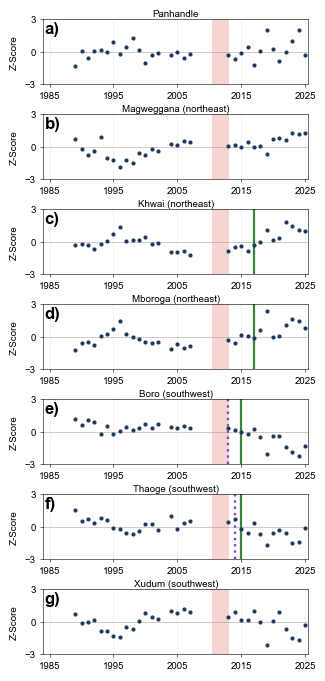

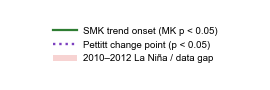

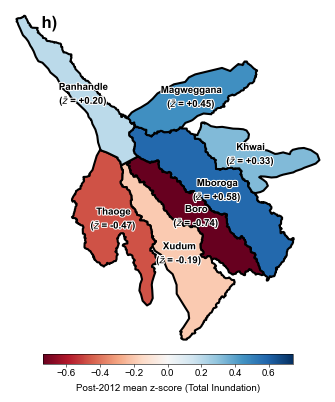

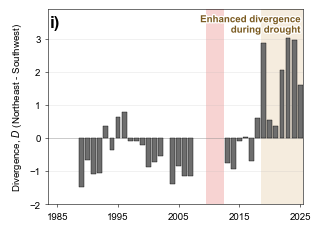

In [15]:
import os
from datetime import datetime

import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ---------------------------------------------------------------------------
# Constants
# ---------------------------------------------------------------------------

POST_START_YEAR  = 2013
POST_START_MONTH = 3 

LINE_COLOR     = "#1f3a5f"   # dark navy markers
PET_LINE_COLOR = "#7B3FBF"   # purple — Pettitt change-point lines (dotted)
SMK_LINE_COLOR = "#2E7D32"   # green — SMK trend-onset lines (solid)
LA_NINA_COLOR  = "#D7261E"   # light red shading for 2010-2012 La Niña gap
DROUGHT_COLOR  = "#C99A4A"   # tan/sand shading for 2019-2025 drought span

BAR_COLOR = "#6E6E6E"        # mid-gray divergence bars

FONT_NAME = "Arial"
TS_FONT_SIZE = 7
TS_TITLE_SIZE = 7
MAP_FONT_SIZE = 7
PANEL_LETTER_SIZE = 12

# Break-line thickness — bumped from 0.9 to 1.6 for visibility.
BREAK_LW = 1.6

# La Niña / data-gap window (used for shading)
LA_NINA_START_YEAR = 2010 + (6 - 1)/12     # June 2010
LA_NINA_END_YEAR   = 2013 + (2 - 1)/12     # Feb 2013

# Drought span for panel i) annotation
DROUGHT_START_YEAR = 2019
DROUGHT_END_YEAR   = 2025

PANEL_LAYOUT = [
    ("Panhandle",  "a", "Panhandle",  "top-left"),
    ("Magweggana", "b", "Magweggana (northeast)", "top-left"),
    ("Khwai",      "c", "Khwai (northeast)",      "top-left"),
    ("Mboroga",    "d", "Mboroga (northeast)",    "top-left"),
    ("Boro",       "e", "Boro (southwest)",       "top-left"),
    ("Thaoge",     "f", "Thaoge (southwest)",     "top-left"),
    ("Xudum",      "g", "Xudum (southwest)",      "top-left"),
]


def _to_fig_coords_for(fig_w_in, fig_h_in):
    """Return a function that converts inch coordinates to figure-relative
    coordinates for a figure of the given dimensions."""
    def _conv(l_in, b_in, w_in, h_in):
        return [l_in / fig_w_in, b_in / fig_h_in,
                w_in / fig_w_in, h_in / fig_h_in]
    return _conv


def _post_period_means(df, dist_names):
    # Filter to months at or after POST_START_YEAR / POST_START_MONTH.
    # The CSV has integer Year and Month columns, so combine them into a
    # single "year-month index" for the comparison.
    ym = df["Year"] * 100 + df["Month"]
    cutoff = POST_START_YEAR * 100 + POST_START_MONTH
    post = df[ym >= cutoff]
    return {dist: float(post[dist].mean()) for dist in dist_names}


# Helper for drawing an un-labeled vertical break line.
def _draw_break_line(ax, year, color, lw=BREAK_LW, ls="-", alpha=0.95):
    ax.axvline(year, color=color, linewidth=lw, linestyle=ls,
               alpha=alpha, zorder=2)


# ---------------------------------------------------------------------------
# Drawing primitives
# ---------------------------------------------------------------------------

def draw_map(fig, map_ax, cbar_ax, df_monthly_z, dist_names,
             distributaries_gdf, cbar_label):
    means = _post_period_means(df_monthly_z, dist_names)

    gdf = distributaries_gdf.copy()
    gdf["mean_z"] = gdf["dist_name"].map(means)
    gdf_web = gdf.to_crs(epsg=3857)

    vmax = float(np.nanmax(np.abs(list(means.values()))))
    norm = Normalize(vmin=-vmax, vmax=vmax)
    cmap = plt.get_cmap("RdBu")

    for _, row in gdf_web.iterrows():
        if row["dist_name"] not in dist_names:
            continue
        single = gdf_web[gdf_web["dist_name"] == row["dist_name"]]
        single.plot(
            ax=map_ax,
            facecolor=cmap(norm(row["mean_z"])),
            edgecolor="black",
            alpha=1.0,
            linewidth=1.5,
        )

        centroid = row.geometry.centroid
        label = f"{row['dist_name']}\n($\\bar{{z}}$ = {row['mean_z']:+.2f})"
        map_ax.text(
            centroid.x, centroid.y, label,
            fontsize=MAP_FONT_SIZE, fontname=FONT_NAME, fontweight="bold",
            ha="center", va="center", color="black",
            path_effects=[pe.withStroke(linewidth=1.5, foreground="white")],
        )

    bounds = gdf_web.total_bounds
    pad = 0.02 * (bounds[2] - bounds[0])
    map_ax.set_xlim(bounds[0] - pad, bounds[2] + pad)
    map_ax.set_ylim(bounds[1] - pad, bounds[3] + pad)

    map_ax.set_aspect("equal")
    map_ax.set_xticks([])
    map_ax.set_yticks([])
    for spine in map_ax.spines.values():
        spine.set_visible(False)
    map_ax.set_xlabel("")
    map_ax.set_ylabel("")

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
    cbar.set_label(cbar_label, fontname=FONT_NAME, fontsize=MAP_FONT_SIZE)
    cbar.ax.tick_params(labelsize=MAP_FONT_SIZE, length=2.0, width=0.4, pad=1.5)
    cbar.outline.set_linewidth(0.4)
    for t in cbar.ax.get_xticklabels():
        t.set_fontname(FONT_NAME)
        t.set_fontsize(MAP_FONT_SIZE)
    cbar_ax.set_facecolor("white")
    for spine in cbar_ax.spines.values():
        spine.set_edgecolor("black")
        spine.set_linewidth(0.4)


def draw_timeseries(ax, df_annual, dist_name, title, pet_year, smk_year):
    """Annual z-score panel with La Niña shading, Pettitt change-point line
    (purple, dotted), and SMK trend-onset line (green, solid)."""
    ax.axvspan(LA_NINA_START_YEAR, LA_NINA_END_YEAR,
               color=LA_NINA_COLOR, alpha=0.20, zorder=0, linewidth=0)

    ax.axhline(0, color="gray", linewidth=0.4, alpha=0.6, zorder=1)

    if smk_year is not None:
        _draw_break_line(ax, smk_year, SMK_LINE_COLOR, ls="-")

    if pet_year is not None:
        _draw_break_line(ax, pet_year, PET_LINE_COLOR, ls=":", lw=BREAK_LW + 0.1)

    ax.plot(df_annual["Year"].values, df_annual[dist_name].values,
            "o", color=LINE_COLOR, markersize=3.0, markeredgewidth=0, zorder=3)

    ax.set_xlim(1984, 2025.5)
    ax.set_ylim(-3, 3)

    years = [1985, 1995, 2005, 2015, 2025]
    ax.set_xticks(years)
    ax.set_xticklabels(years, fontname=FONT_NAME, fontsize=TS_FONT_SIZE)

    ax.set_yticks([-3, 0, 3])
    for t in ax.get_yticklabels():
        t.set_fontname(FONT_NAME)
        t.set_fontsize(TS_FONT_SIZE)
    ax.set_ylabel("Z-Score", fontname=FONT_NAME, fontsize=TS_FONT_SIZE)

    ax.tick_params(axis="both", labelsize=TS_FONT_SIZE, length=2.0, width=0.4)

    ax.grid(True, alpha=0.3, linewidth=0.4)
    for spine in ax.spines.values():
        spine.set_linewidth(0.4)

    ax.set_title(title, fontname=FONT_NAME, fontsize=TS_TITLE_SIZE, pad=2)


def draw_divergence_bars(ax, div_df):
    years = div_df["Year"].astype(int).values
    D = div_df["D"].values

    # La Niña / data-gap shading
    ax.axvspan(2009.5, 2012.5,
               color=LA_NINA_COLOR, alpha=0.20, zorder=0, linewidth=0)

    # Drought shading — 2019-2025
    ax.axvspan(DROUGHT_START_YEAR - 0.5, DROUGHT_END_YEAR + 0.5,
               color=DROUGHT_COLOR, alpha=0.18, zorder=0, linewidth=0)

    ax.axhline(0, color="gray", linewidth=0.4, alpha=0.6, zorder=1)
    ax.bar(years, D, color=BAR_COLOR, edgecolor="black",
           linewidth=0.3, width=0.8, zorder=2)

    ax.set_xlim(1983.5, 2025.5)
    year_ticks = [1985, 1995, 2005, 2015, 2025]
    ax.set_xticks(year_ticks)
    ax.set_xticklabels(year_ticks, fontname=FONT_NAME, fontsize=TS_FONT_SIZE)

    ymax = float(np.nanmax(np.abs(D))) if len(D) else 1.0
    y_top = max(1.0, np.ceil(ymax * 2) / 2 + 0.4)
    y_bottom = -2.0
    ax.set_ylim(y_bottom, y_top)
    yticks = np.arange(np.ceil(y_bottom), np.floor(y_top) + 0.5, 1.0)
    ax.set_yticks(yticks)
    for t in ax.get_yticklabels():
        t.set_fontname(FONT_NAME)
        t.set_fontsize(TS_FONT_SIZE)

    ax.set_ylabel(r"Divergence, $\it{D}$ (Northeast - Southwest)",
                  fontname=FONT_NAME, fontsize=TS_FONT_SIZE)

    ax.tick_params(axis="both", labelsize=TS_FONT_SIZE, length=2.0, width=0.4)
    ax.grid(True, axis="y", alpha=0.3, linewidth=0.4)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_linewidth(0.4)

    # Drought annotation — top-right corner of panel i)
    ax.text(0.99, 0.97, "Enhanced divergence\nduring drought",
            transform=ax.transAxes,
            fontname=FONT_NAME, fontsize=TS_FONT_SIZE,
            color="#7A5A20", fontweight="bold",
            ha="right", va="top", zorder=5,
            path_effects=[pe.withStroke(linewidth=1.8, foreground="white")])


def add_panel_letter(ax, letter, position="top-left", halo=False, x=None, y=None):
    if position == "top-left":
        if x is None:
            x = 0.005
        if y is None:
            y = 0.97
        va = "top"
    elif position == "bottom-left":
        if x is None:
            x = 0.005
        if y is None:
            y = 0.07
        va = "bottom"
    else:
        raise ValueError(f"Unknown letter position: {position}")

    kwargs = dict(
        transform=ax.transAxes,
        fontname=FONT_NAME, fontsize=PANEL_LETTER_SIZE, fontweight="bold",
        ha="left", va=va,
        zorder=10,
    )
    if halo:
        kwargs["path_effects"] = [pe.withStroke(linewidth=1.5, foreground="white")]
    ax.text(x, y, f"{letter})", **kwargs)


# Save helper — 1000 DPI, transparent.
def _save_fig(fig, stem):
    for ext in ("png", "pdf"):
        path = f"{stem}.{ext}"
        fig.savefig(path, dpi=1000, transparent=True, bbox_inches=None)
        print(f"  ✓ Saved {path}")
    # JPG can't be transparent, but kept for compatibility.
    jpg_path = f"{stem}.jpg"
    fig.savefig(jpg_path, dpi=1000, facecolor="white", bbox_inches=None)
    print(f"  ✓ Saved {jpg_path}")


# ---------------------------------------------------------------------------
# Common setup
# ---------------------------------------------------------------------------

plt.rcParams["font.family"] = FONT_NAME

df_z_monthly = pd.read_csv(CSV_ZMONTHLY)


# ===========================================================================
# FIGURE 1: Time-series panels a–g  (3.25" wide × 7" tall)
# ===========================================================================

FIG1_W = 3.25
FIG1_H = 7.00

# Layout for the 7-panel column.
TS_AXES_L = 0.45                  # left margin for y-axis labels
TS_AXES_R_PAD = 0.15              # right margin (needs to clear the '2025' tick label)
TS_AXES_W = FIG1_W - TS_AXES_L - TS_AXES_R_PAD   # 2.65"
TS_AXES_H = 0.65
TS_SLOT_H = 0.95
TS_TITLE_PAD = 0.18
TS_TOP_MARGIN = 0.10

# Sanity check: top + 7 slots should fit in FIG1_H with room to spare.
# 0.10 + 7 * 0.95 = 6.75, leaving 0.25" at the bottom.
TS_TOP_Y = FIG1_H - TS_TOP_MARGIN
fig1 = plt.figure(figsize=(FIG1_W, FIG1_H))
fig1.patch.set_alpha(0.0)
to_coords_1 = _to_fig_coords_for(FIG1_W, FIG1_H)
for index, (dist, letter, title, letter_pos) in enumerate(PANEL_LAYOUT):
    slot_top = TS_TOP_Y - index * TS_SLOT_H
    axes_top = slot_top - TS_TITLE_PAD
    axes_bottom = axes_top - TS_AXES_H
    ax = fig1.add_axes(to_coords_1(TS_AXES_L, axes_bottom, TS_AXES_W, TS_AXES_H))
    r = results_by_dist[dist]
    pet_year = r['cp_year'] if r['pet_sig'] else None
    smk_year = r['smk_onset_year'] if r['mk_sig'] else None
    draw_timeseries(ax, df_annual, dist, title, pet_year, smk_year)
    add_panel_letter(ax, letter, position=letter_pos)
_save_fig(fig1, f"{FIG_OUT_STEM}_panels_a-g")


# ===========================================================================
# FIGURE 2: Legend  (separate small figure, no border)
# ===========================================================================

LEG_W = 2.5
LEG_H = 0.7

fig2 = plt.figure(figsize=(LEG_W, LEG_H))
fig2.patch.set_alpha(0.0)
leg_ax = fig2.add_axes([0, 0, 1, 1])
leg_ax.axis("off")

legend_handles = [
    Line2D([0], [0], color=SMK_LINE_COLOR, lw=BREAK_LW, ls="-",
           label="SMK trend onset (MK p < 0.05)"),
    Line2D([0], [0], color=PET_LINE_COLOR, lw=BREAK_LW + 0.1, ls=":",
           label="Pettitt change point (p < 0.05)"),
    Patch(facecolor=LA_NINA_COLOR, alpha=0.20, edgecolor="none",
          label="2010–2012 La Niña / data gap"),
]
leg_ax.legend(
    handles=legend_handles,
    loc="center",
    fontsize=TS_FONT_SIZE,
    ncol=1,
    frameon=False,
    handlelength=2.5,
    handletextpad=0.6,
    borderpad=0.4,
    labelspacing=0.5,
)

_save_fig(fig2, f"{FIG_OUT_STEM}_legend")


# ===========================================================================
# FIGURE 3: Map panel  (3.25" wide × 5" tall)
# ===========================================================================

FIG3_W = 3.25
FIG3_H = 5.00

# To avoid empty axes padding from `aspect='equal'`, we size the map axes
# to the data's own aspect ratio. Read the bounds from the projected
# geodataframe (EPSG:3857) and compute width:height.
_gdf_web_for_bounds = distributaries_gdf.to_crs(epsg=3857)
_bounds = _gdf_web_for_bounds.total_bounds   # (minx, miny, maxx, maxy)
_data_w = _bounds[2] - _bounds[0]
_data_h = _bounds[3] - _bounds[1]
_data_aspect = _data_w / _data_h             # width / height in data units

# Reserve space for the colorbar + its label below the map.
CBAR_H_IN          = 0.10
CBAR_LABEL_PAD_IN  = 0.30   # below cbar for tick labels + cbar label
CBAR_TO_MAP_GAP_IN = 0.08   # tight gap between map bottom and cbar top
MAP_TOP_MARGIN     = 0.10
MAP_BOTTOM_RESERVE = CBAR_H_IN + CBAR_LABEL_PAD_IN + CBAR_TO_MAP_GAP_IN

# Max available height and width for the map axes.
MAX_MAP_H = FIG3_H - MAP_TOP_MARGIN - MAP_BOTTOM_RESERVE
MAX_MAP_W = FIG3_W - 0.10   # 0.05" side margins

# Pick map axes dimensions that match the data aspect, capped by the
# available space.
if MAX_MAP_W / MAX_MAP_H > _data_aspect:
    # height-limited: use all available height, scale width to match aspect
    MAP_H = MAX_MAP_H
    MAP_W = MAP_H * _data_aspect
else:
    # width-limited: use all available width, scale height to match aspect
    MAP_W = MAX_MAP_W
    MAP_H = MAP_W / _data_aspect

# Center the map horizontally in the figure.
MAP_L = (FIG3_W - MAP_W) / 2
MAP_B = FIG3_H - MAP_TOP_MARGIN - MAP_H

# Colorbar sits directly under the map.
CBAR_W = min(2.50, MAP_W * 0.9)
CBAR_L = (FIG3_W - CBAR_W) / 2
CBAR_B = MAP_B - CBAR_TO_MAP_GAP_IN - CBAR_H_IN

fig3 = plt.figure(figsize=(FIG3_W, FIG3_H))
fig3.patch.set_alpha(0.0)
to_coords_3 = _to_fig_coords_for(FIG3_W, FIG3_H)

map_ax = fig3.add_axes(to_coords_3(MAP_L, MAP_B, MAP_W, MAP_H))
cbar_ax = fig3.add_axes(to_coords_3(CBAR_L, CBAR_B, CBAR_W, CBAR_H_IN))

pre_start_year = POST_START_YEAR - 1

DATASET_LABEL = {'TotalInundation': 'Total Inundation',
                 'OpenWater': 'Open Water'}.get(DATASET, DATASET)
cbar_label = f"Post-{pre_start_year} mean z-score ({DATASET_LABEL})"
draw_map(fig3, map_ax, cbar_ax, df_z_monthly, EXPECTED_NAMES,
         distributaries_gdf, cbar_label)

# Panel letter "h)" — now that the axes are sized to the data, the
# top-left of the axes coincides with the top-left of the data bounds,
# so axes-coord placement is correct.
add_panel_letter(map_ax, "h", position="top-left", halo=True, x=0.1, y=0.98)

_save_fig(fig3, f"{FIG_OUT_STEM}_map_h")


# ===========================================================================
# FIGURE 4: Divergence bar panel i)  (3.25" wide × 2.5" tall)
# ===========================================================================

FIG4_W = 3.25
FIG4_H = 2.50

BAR_L = 0.55
BAR_R_PAD = 0.15                               # match panels a–g, clears '2025' label
BAR_W = FIG4_W - BAR_L - BAR_R_PAD             # 2.55"
BAR_TOP_MARGIN = 0.15
BAR_BOTTOM_MARGIN = 0.40                       # x-axis tick labels
BAR_H = FIG4_H - BAR_TOP_MARGIN - BAR_BOTTOM_MARGIN   # 2.45"
BAR_B = BAR_BOTTOM_MARGIN

fig4 = plt.figure(figsize=(FIG4_W, FIG4_H))
fig4.patch.set_alpha(0.0)
to_coords_4 = _to_fig_coords_for(FIG4_W, FIG4_H)

bar_ax = fig4.add_axes(to_coords_4(BAR_L, BAR_B, BAR_W, BAR_H))
draw_divergence_bars(bar_ax, df_div)
add_panel_letter(bar_ax, "i", position="top-left")

_save_fig(fig4, f"{FIG_OUT_STEM}_panel_i")


plt.show()

## §8 · Summary

This notebook produced, in order:

| Step | Output |
|---|---|
| §2 | `Distributary_InundationMonthly_<DATASET>.csv` |
| §3 | `Distributary_ZScoresMonthly_<DATASET>.csv` |
| §4 | `Distributary_ZScoresAnnual_<DATASET>.csv` |
| §5 | `Distributary_TrendTests_<DATASET>.csv` + SMK diagnostic figure (`FigureS2_TotalInundation` or `FigureS3_OpenWater`) |
| §6 | `Dryness_Divergence_Annual_<DATASET>.csv` |
| §7 | Composite figure pieces (`Figure3_TotalInundation_*` or `FigureS1_OpenWater_*`) |

To run the other dataset, change `DATASET` in §0 and re-run §2 onward (the
monthly inundation CSV from §2 is dataset-specific, so §2 also needs re-running
with the new threshold).

### Method references

- Mann (1945); Kendall (1975) — Mann–Kendall trend test
- Sen (1968) — Sen's slope (used internally for TFPW detrending; not reported)
- Sneyers (1990) — sequential Mann–Kendall and onset reporting criteria
- Pettitt (1979) — change-point test (rank formulation)
- Yue, Pilon, Phinney & Cavadias (2002) — trend-free pre-whitening
- Douglas, Vogel & Kroll (2000) — conditional application
  of pre-whitening
- Benjamini & Hochberg (1995) — false-discovery-rate control
  across multiple sites
- Serinaldi & Kilsby (2016) — inflation of change-point false-positive rates under
  serial correlation; motivation for the Monte-Carlo AR(1) null